In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score


In [ ]:
from google.colab import files
uploaded = files.upload()
file_path = "wbc_dataset_features.csv"
df = pd.read_csv(file_path)

Saving wbc_dataset_features.csv to wbc_dataset_features.csv


In [ ]:
# Target and numeric features
y = df["Label"]
X = df.select_dtypes(include=["number"])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9216071428571428

Classification Report:
               precision    recall  f1-score   support

    basophil       0.91      0.93      0.92       700
  eosinophil       0.99      0.93      0.96       700
erythroblast       0.94      0.90      0.92       700
          ig       0.82      0.82      0.82       700
  lymphocyte       0.92      0.96      0.94       700
    monocyte       0.91      0.92      0.92       700
  neutrophil       0.92      0.95      0.94       700
    platelet       0.96      0.95      0.96       700

    accuracy                           0.92      5600
   macro avg       0.92      0.92      0.92      5600
weighted avg       0.92      0.92      0.92      5600



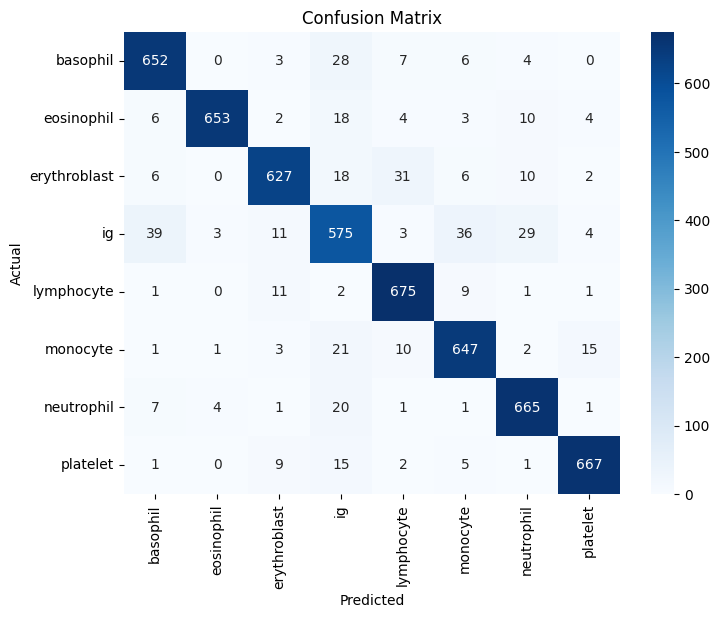

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

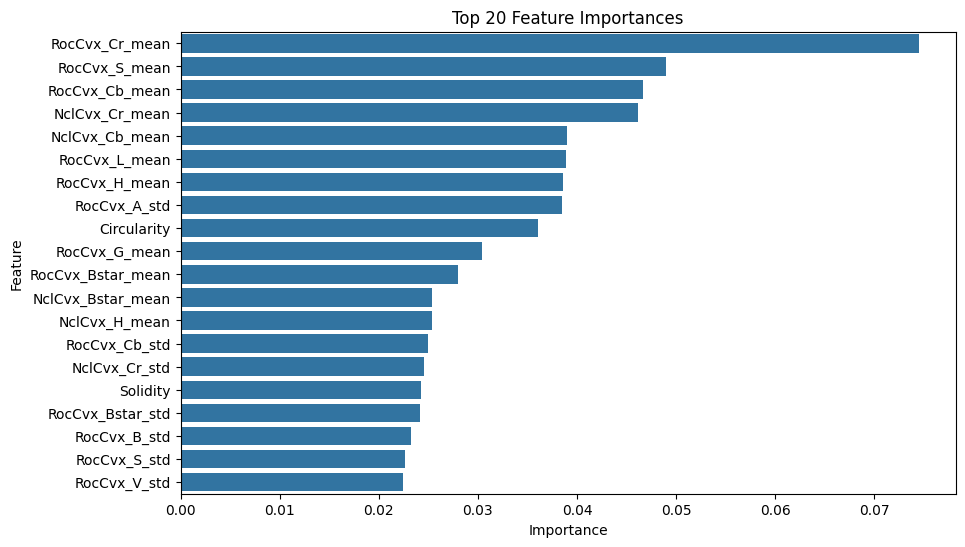

In [ ]:
#Features Importance
importances = rf_model.feature_importances_
features = X.columns

feat_imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df.head(20))
plt.title("Top 20 Feature Importances")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

joblib.dump(rf_model, "/content/drive/MyDrive/random_forest_wbc_model.pkl")
print("Model saved to Google Drive successfully!")

Mounted at /content/drive
Model saved to Google Drive successfully!


In [ ]:
# Select top 10 features
top_n = 10
top_features = feat_imp_df.head(top_n)["Feature"].values

X_reduced = X[top_features]

# Train-test split again
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
rf_model_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_reduced.fit(X_train, y_train)

# Evaluate
y_pred = rf_model_reduced.predict(X_test)
print("Accuracy with top features:", accuracy_score(y_test, y_pred))

Accuracy with top features: 0.8942857142857142


In [ ]:
#Dropping correlated features
import numpy as np

corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

X_reduced = X.drop(columns=to_drop)

print("Dropped correlated features:", to_drop)



Dropped correlated features: ['NclCvx_S_mean', 'NclCvx_L_mean', 'NclCvx_A_mean', 'NclCvx_Bstar_mean', 'NclCvx_Cb_mean', 'NclCvx_G_std', 'NclCvx_S_std', 'NclCvx_V_std', 'NclCvx_L_std', 'NclCvx_A_std', 'NclCvx_Bstar_std', 'NclCvx_Y_std', 'NclCvx_Cb_std', 'RocCvx_L_mean', 'RocCvx_Bstar_mean', 'RocCvx_Cb_mean', 'RocCvx_S_std', 'RocCvx_V_std', 'RocCvx_L_std', 'RocCvx_A_std', 'RocCvx_Bstar_std', 'RocCvx_Y_std', 'RocCvx_Cb_std']


In [ ]:
# Remove correlated features
X_reduced = X.drop(columns=to_drop)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
rf_model_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_reduced.fit(X_train, y_train)

# Evaluate
y_pred = rf_model_reduced.predict(X_test)

print("Accuracy after removing correlated features:",
      accuracy_score(y_test, y_pred))

Accuracy after removing correlated features: 0.9139285714285714


In [ ]:

#  ORIGINAL MODEL


# Train using all features
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_full.fit(X_train_full, y_train_full)

y_pred_full = rf_full.predict(X_test_full)
acc_full = accuracy_score(y_test_full, y_pred_full)



#  REDUCED MODEL


X_reduced = X.drop(columns=to_drop)

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_reduced.fit(X_train_red, y_train_red)

y_pred_red = rf_reduced.predict(X_test_red)
acc_red = accuracy_score(y_test_red, y_pred_red)



# RESULTS


print("Original Accuracy: ", acc_full)
print("Reduced Accuracy:  ", acc_red)
print("Difference:        ", acc_red - acc_full)

Original Accuracy:  0.9198214285714286
Reduced Accuracy:   0.9139285714285714
Difference:         -0.005892857142857144


In [ ]:
#Hyperparameter Tuning (Grid Search)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': None, 'n_estimators': 200}


In [ ]:
# Evaluation after Tuning
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


              precision    recall  f1-score   support

    basophil       0.91      0.93      0.92       700
  eosinophil       0.99      0.91      0.95       700
erythroblast       0.94      0.89      0.91       700
          ig       0.82      0.83      0.82       700
  lymphocyte       0.90      0.95      0.93       700
    monocyte       0.89      0.91      0.90       700
  neutrophil       0.92      0.95      0.93       700
    platelet       0.96      0.96      0.96       700

    accuracy                           0.91      5600
   macro avg       0.92      0.91      0.91      5600
weighted avg       0.92      0.91      0.91      5600

Confusion Matrix:
[[654   1   2  24   7   6   6   0]
 [  9 635   3  30   4   5  11   3]
 [  8   1 622  16  35   6  10   2]
 [ 36   2   9 579   5  37  27   5]
 [  2   0  16   2 665  14   1   0]
 [  1   0   1  25  16 636   3  18]
 [  6   4   0  23   1   1 663   2]
 [  0   0  11  11   2   7   0 669]]


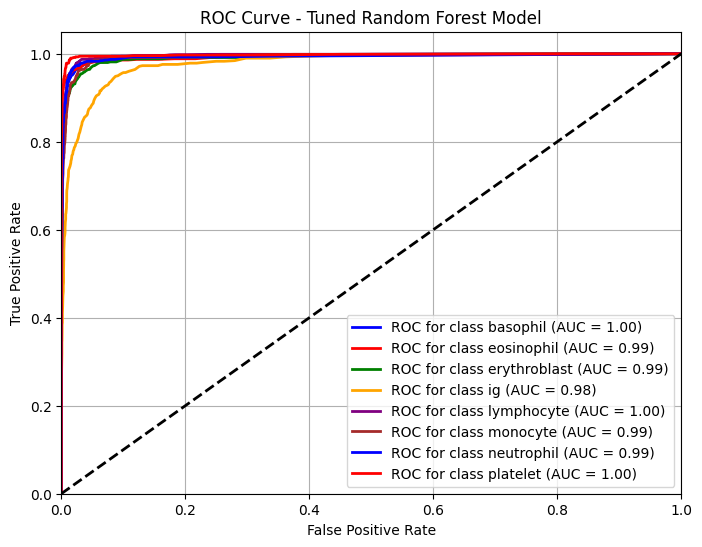

In [ ]:
# ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# Binarize the test labels using model classes
classes = best_rf.classes_
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Get probability predictions from tuned Random Forest
y_score = best_rf.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))

colors = cycle(['blue','red','green','orange','purple','brown'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"ROC for class {classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Random classifier line
plt.plot([0,1], [0,1], 'k--', lw=2)

plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest Model")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()